# 📈 Modelo: Regressão Logística
**Dataset:** Sonar – Classificação de Minas vs Rochas  
**Algoritmo:** LogisticRegression (scikit-learn)  
**Pipeline:** StandardScaler → LogisticRegression (max_iter=1000)


## 1. Importações e Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


## 2. Carregamento dos Dados

In [2]:
PATH = r"C:\Users\Usuário\Documents\paradigmas-programacao\dataset_1_matriz\sonar_data_matriz.csv"

df = pd.read_csv(PATH)
print("Shape:", df.shape)
print("\nDistribuição de classes:")
print(df.iloc[:, -1].value_counts())
df.head()


Shape: (207, 61)

Distribuição de classes:
R
M    111
R     96
Name: count, dtype: int64


,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R


## 3. Pré-processamento

In [ ]:
LABEL = df.columns[-1]
X = df.drop(columns=[LABEL])
y = df[LABEL]

le = LabelEncoder()
y = le.fit_transform(y) # M=1, R=0
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40, stratify=y
)

print(f"Treino : {X_train.shape[0]} amostras  |  Teste: {X_test.shape[0]} amostras")
print(f"Classes originais : {le.classes_}  → codificadas: {le.transform(le.classes_)}")


Treino : 165 amostras  |  Teste: 42 amostras
Classes originais : ['M' 'R']  → codificadas: [0 1]


## 4. Pipeline e Treinamento

In [4]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(max_iter=1000, random_state=40))
])

pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Pipeline treinado ✔  (StandardScaler → LogisticRegression)")


Pipeline treinado ✔  (StandardScaler → LogisticRegression)


## 5. Métricas de Desempenho

In [5]:
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

metricas = {
    "Acurácia"         : acc,
    "Precisão (Mina)"  : precision,
    "Recall (Mina)"    : recall,
    "F1-Score (Mina)"  : f1,
    "ROC-AUC"          : roc_auc,
    "CV Acurácia (5x)" : cv_scores.mean(),
}

df_metricas = pd.DataFrame(metricas.items(), columns=["Métrica", "Valor"])
df_metricas["Valor"] = df_metricas["Valor"].map(lambda v: f"{v:.4f}")
print("=== MÉTRICAS – REGRESSÃO LOGÍSTICA ===")
display(df_metricas)


=== MÉTRICAS – REGRESSÃO LOGÍSTICA ===


,Métrica,Valor
0,Acurácia,0.8095
1,Precisão (Mina),0.8667
2,Recall (Mina),0.6842
3,F1-Score (Mina),0.7647
4,ROC-AUC,0.8032
5,CV Acurácia (5x),0.6432


## 6. Matriz de Confusão

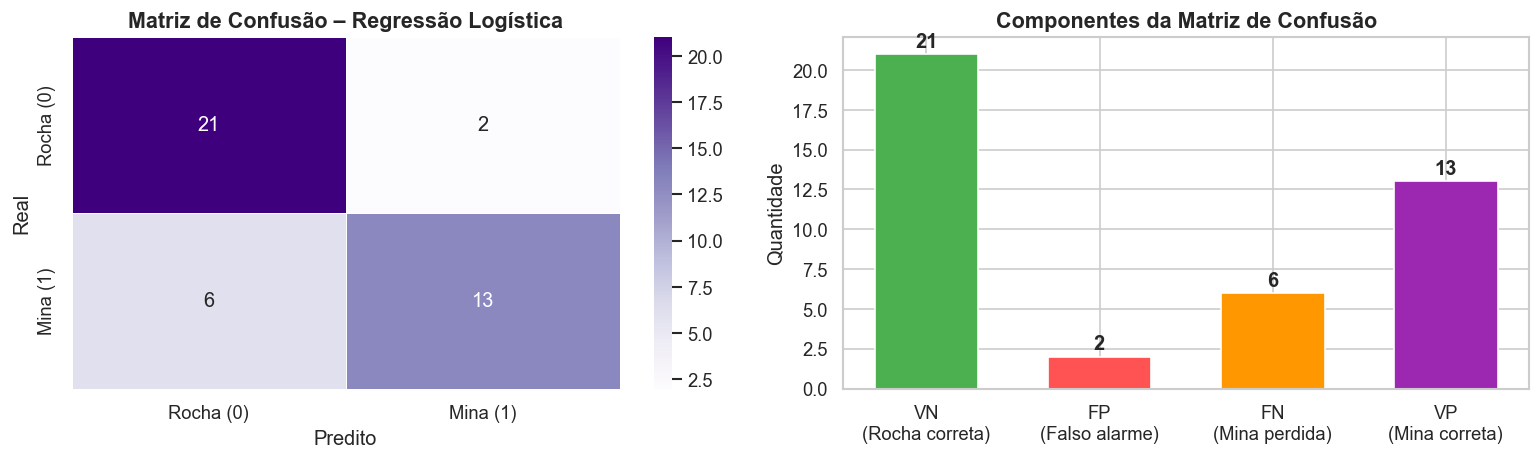


VN=21  FP=2  FN=6  VP=13


In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Rocha (0)', 'Mina (1)'],
            yticklabels=['Rocha (0)', 'Mina (1)'],
            ax=axes[0], linewidths=.5)
axes[0].set_title('Matriz de Confusão – Regressão Logística', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predito')

labels = ['VN\n(Rocha correta)', 'FP\n(Falso alarme)', 'FN\n(Mina perdida)', 'VP\n(Mina correta)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['#4CAF50', '#FF5252', '#FF9800', '#9C27B0']
bars = axes[1].bar(labels, values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Componentes da Matriz de Confusão', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.savefig('../images/lr_matriz_confusao.png', bbox_inches='tight')
plt.show()

print(f"\nVN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  VP={cm[1,1]}")


## 7. Curva ROC

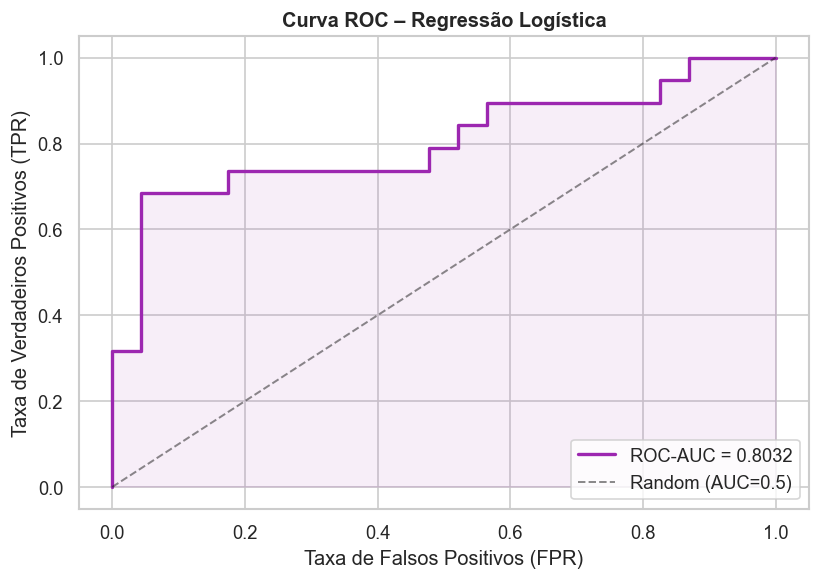

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#9C27B0', lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5, label='Random (AUC=0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#9C27B0')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.set_title('Curva ROC – Regressão Logística', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../images/lr_roc.png', bbox_inches='tight')
plt.show()


## 8. Relatório de Classificação

In [8]:
print(classification_report(y_test, y_pred, target_names=["Rocha (0)", "Mina (1)"]))


              precision    recall  f1-score   support

   Rocha (0)       0.78      0.91      0.84        23
    Mina (1)       0.87      0.68      0.76        19

    accuracy                           0.81        42
   macro avg       0.82      0.80      0.80        42
weighted avg       0.82      0.81      0.81        42



## 9. Validação Cruzada (5-fold)

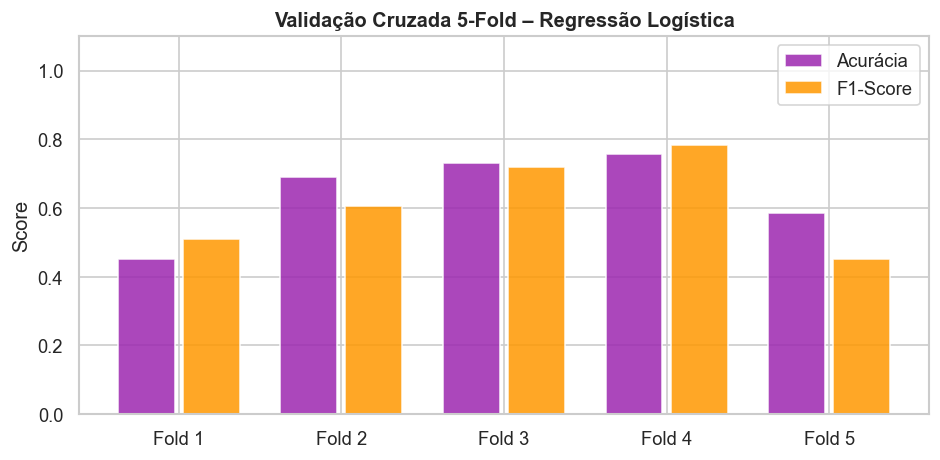

Acurácia CV → média=0.6432  std=0.1119
F1-Score CV → média=0.6138   std=0.1236


In [12]:
cv_acc = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
cv_f1  = cross_val_score(pipeline, X, y, cv=5, scoring='f1')

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(5)
ax.bar(x - 0.2, cv_acc, 0.35, label='Acurácia', color='#9C27B0', alpha=0.85)
ax.bar(x + 0.2, cv_f1,  0.35, label='F1-Score',  color='#FF9800', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Validação Cruzada 5-Fold – Regressão Logística', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../images/lr_cv.png', bbox_inches='tight')
plt.show()

print(f"Acurácia CV → média={cv_acc.mean():.4f}  std={cv_acc.std():.4f}")
print(f"F1-Score CV → média={cv_f1.mean():.4f}   std={cv_f1.std():.4f}")


## 10. Sumário Final

In [10]:
sumario = pd.DataFrame({
    "Modelo"           : ["Regressão Logística"],
    "Acurácia"         : [round(acc, 4)],
    "Precisão"         : [round(precision, 4)],
    "Recall"           : [round(recall, 4)],
    "F1-Score"         : [round(f1, 4)],
    "ROC-AUC"          : [round(roc_auc, 4)],
    "CV Acurácia (μ)"  : [round(cv_scores.mean(), 4)],
})
print("=== SUMÁRIO – REGRESSÃO LOGÍSTICA ===")
display(sumario)


=== SUMÁRIO – REGRESSÃO LOGÍSTICA ===


,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC,CV Acurácia (μ)
0,Regressão Logística,0.8095,0.8667,0.6842,0.7647,0.8032,0.6432
